# Tra cứu Luật An toàn, vệ sinh lao động bằng NLP tiếng Việt

**Đồ án môn Máy học (UIT).** Bài toán: phân loại câu hỏi tiếng Việt vào 8 nhóm quy định của Luật ATVSLĐ 84/2015/QH13
(văn bản hợp nhất 14/VBHN-VPQH 2024), sau đó tra cứu Điều luật cụ thể bằng cosine similarity.

Nội dung: (1) Mô tả dữ liệu, (2) EDA, (3) Tiền xử lý, (4) Chia dữ liệu chống leakage, (5) 4 mô hình + GridSearchCV,
(6) Đánh giá, (7) Ablation study, (8) Phân tích lỗi, (9) Test trên câu hỏi thật, (10) Tra cứu Điều luật.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from src.config import LABELS, LABEL_CODES, ARTICLE_TO_LABEL, FIGURES_DIR, MODELS_DIR, RANDOM_STATE
from src.dataset import load_dataset, load_real_test, load_real_ood
from src.preprocess import preprocess, normalize
from src.models import build_models, fit_eval, scores, tfidf
from src.retrieval import ArticleRetriever, topk_accuracy

plt.rcParams.update({"figure.dpi": 110, "font.family": "Arial Unicode MS", "axes.titlesize": 11})
FIGURES_DIR.mkdir(parents=True, exist_ok=True); MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS = {}  # gom số liệu để sinh báo cáo
CODES = [LABEL_CODES[k] for k in sorted(LABEL_CODES)]
def savefig(name): plt.tight_layout(); plt.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight"); plt.show()

## 1. Mô tả bộ dữ liệu

- **Corpus Điều luật:** 93 Điều (parse từ VBHN 14/VBHN-VPQH bằng `scripts/build_articles.py`). Phạm vi phân loại: Đ1–62, 8 lớp.
- **Tập câu hỏi chính (synthetic):** do mô hình ngôn ngữ lớn (Claude) sinh từ nội dung từng Điều theo `docs/labeling-guidelines.md`: 40 câu gốc (seed) mỗi lớp, mỗi seed có 5 biến thể văn phong
  (trung tính, công nhân, nhân sự/HSE, khiếu nại, rút gọn). Nhãn **suy ra từ Điều đích** (`label = ARTICLE_TO_LABEL[article_id]`), mô hình sinh không chọn lớp. Kiểm bằng `scripts/validate_generated.py`.
- **Tập test thật:** câu hỏi của người dân trên Cổng Hỏi đáp chính sách (chinhsachonline.chinhphu.vn). Nhãn do mô hình ngôn ngữ lớn (GPT) gán theo Điều mà cơ quan trả lời viện dẫn, sau đó kiểm chứng bằng gán nhãn mù của một thành viên (`scripts/blind_labeling.py`, kết quả `reports/agreement.json`; phiếu thứ hai do AI hỗ trợ nên chỉ tính là LLM thứ hai).

In [2]:
df = load_dataset()
print("Tổng số mẫu:", len(df), "| số seed:", df.seed_id.nunique(), "| số lớp:", df.label_id.nunique())
dist = df.groupby(["label_id", "label_code"]).agg(so_mau=("id", "size"), so_seed=("seed_id", "nunique"),
                                                   so_dieu=("article_id", "nunique")).reset_index()
dist["ty_le_%"] = (dist.so_mau / dist.so_mau.sum() * 100).round(1)
RESULTS["n_samples"] = int(len(df)); RESULTS["n_seeds"] = int(df.seed_id.nunique())
RESULTS["class_dist"] = dist.to_dict("records")
dist

Tổng số mẫu: 1600 | số seed: 320 | số lớp: 8


,label_id,label_code,so_mau,so_seed,so_dieu,ty_le_%
0,0,QUY_DINH_CHUNG,200,40,12,12.5
1,1,BIEN_PHAP_PHONG_NGUA,200,40,15,12.5
2,2,PHUONG_TIEN_BAO_HO,200,40,1,12.5
3,3,SUC_KHOE_BOI_DUONG,200,40,4,12.5
4,4,KHAI_BAO_DIEU_TRA,200,40,4,12.5
5,5,CHE_DO_BOI_THUONG,200,40,3,12.5
6,6,HUAN_LUYEN_ATLD,200,40,1,12.5
7,7,BAO_HIEM_TNLD,200,40,22,12.5


### Phân chia Train / Val / Test theo nhóm seed

In [3]:
split_tab = pd.crosstab(df.label_code, df.split).reindex(CODES)[["train", "val", "test"]]
split_tab.loc["TỔNG"] = split_tab.sum()
RESULTS["split_sizes"] = df.split.value_counts().to_dict()
RESULTS["split_table"] = split_tab.reset_index().to_dict("records")
# Kiểm tra chống leakage: không seed nào nằm ở 2 tập
s = {k: set(df.loc[df.split == k, "seed_id"]) for k in ["train", "val", "test"]}
print("Seed giao train∩val:", len(s["train"] & s["val"]), "| train∩test:", len(s["train"] & s["test"]),
      "| val∩test:", len(s["val"] & s["test"]))
split_tab

Seed giao train∩val: 0 | train∩test: 0 | val∩test: 0


split,train,val,test
label_code,,,
QUY_DINH_CHUNG,145,30,25
BIEN_PHAP_PHONG_NGUA,140,30,30
PHUONG_TIEN_BAO_HO,145,30,25
SUC_KHOE_BOI_DUONG,140,30,30
KHAI_BAO_DIEU_TRA,145,25,30
CHE_DO_BOI_THUONG,140,30,30
HUAN_LUYEN_ATLD,140,30,30
BAO_HIEM_TNLD,145,25,30
TỔNG,1140,230,230


In [4]:
real = load_real_test()
if real is not None:
    real["question_clean"] = real.question.map(preprocess)
    print("Test thật:", len(real), "câu"); RESULTS["n_real"] = int(len(real))
    display(real.label_code.value_counts().reindex(CODES).fillna(0).astype(int).to_frame("so_cau"))
else:
    print("Chưa có tập test thật"); RESULTS["n_real"] = 0
ood = load_real_ood()
if ood is not None:
    ood["question_clean"] = ood.question.map(preprocess)
    RESULTS["n_real_ood"] = int(len(ood))
    print("Câu hỏi thật ngoài phạm vi (OOD, chỉ dùng đo ngưỡng từ chối):", len(ood))

Test thật: 42 câu


,so_cau
label_code,
QUY_DINH_CHUNG,1
BIEN_PHAP_PHONG_NGUA,10
PHUONG_TIEN_BAO_HO,0
SUC_KHOE_BOI_DUONG,3
KHAI_BAO_DIEU_TRA,1
CHE_DO_BOI_THUONG,15
HUAN_LUYEN_ATLD,1
BAO_HIEM_TNLD,11


Câu hỏi thật ngoài phạm vi (OOD, chỉ dùng đo ngưỡng từ chối): 127


## 2. Phân tích khám phá dữ liệu (EDA)

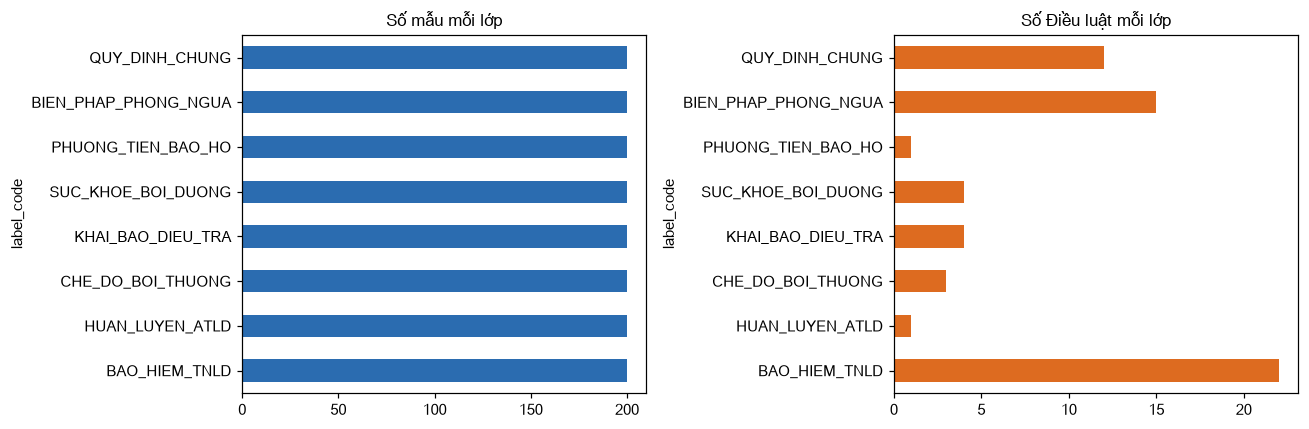

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dist.set_index("label_code").so_mau.plot.barh(ax=ax[0], color="#2b6cb0"); ax[0].set_title("Số mẫu mỗi lớp"); ax[0].invert_yaxis()
dist.set_index("label_code").so_dieu.plot.barh(ax=ax[1], color="#dd6b20"); ax[1].set_title("Số Điều luật mỗi lớp"); ax[1].invert_yaxis()
savefig("eda_class_distribution")

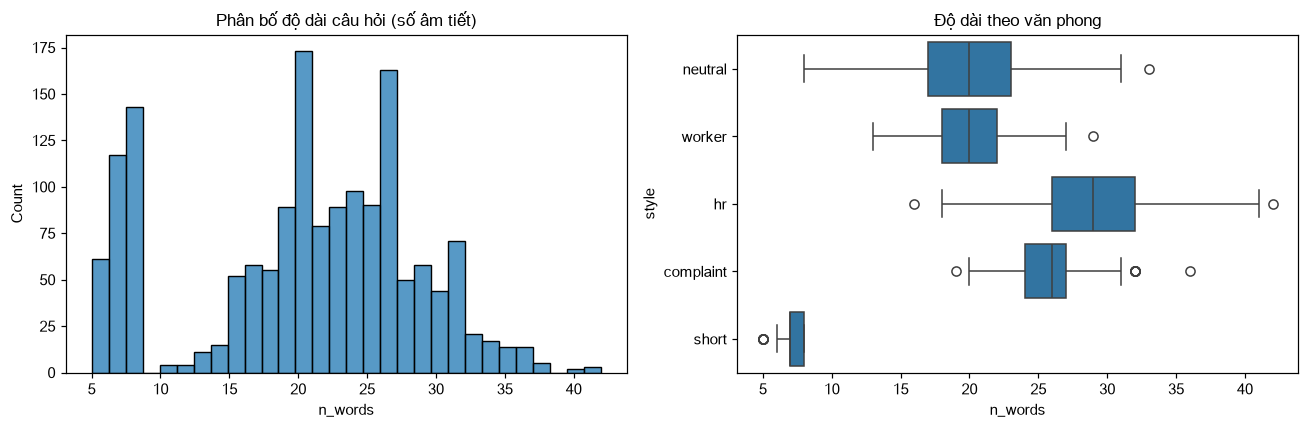

,count,mean,std,min,25%,50%,75%,max
label_code,,,,,,,,
BAO_HIEM_TNLD,200.0,21.6,8.8,5.0,18.0,22.5,28.0,41.0
BIEN_PHAP_PHONG_NGUA,200.0,20.6,7.8,6.0,17.0,22.0,26.0,38.0
CHE_DO_BOI_THUONG,200.0,22.2,8.8,6.0,19.0,24.0,28.2,42.0
HUAN_LUYEN_ATLD,200.0,20.3,8.1,5.0,16.0,21.0,26.0,36.0
KHAI_BAO_DIEU_TRA,200.0,21.1,8.5,6.0,16.8,23.0,27.2,40.0
PHUONG_TIEN_BAO_HO,200.0,19.9,7.7,5.0,16.0,21.0,25.0,41.0
QUY_DINH_CHUNG,200.0,19.5,7.6,5.0,14.0,21.0,25.0,34.0
SUC_KHOE_BOI_DUONG,200.0,18.9,7.4,6.0,14.0,20.0,25.0,35.0


In [6]:
df["n_words"] = df.question.str.split().str.len()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.n_words, bins=30, ax=ax[0]); ax[0].set_title("Phân bố độ dài câu hỏi (số âm tiết)")
sns.boxplot(data=df, x="n_words", y="style", ax=ax[1]); ax[1].set_title("Độ dài theo văn phong")
savefig("eda_length")
RESULTS["len_stats"] = df.n_words.describe().round(1).to_dict()
RESULTS["len_by_style"] = df.groupby("style").n_words.mean().round(1).to_dict()
df.groupby("label_code").n_words.describe().round(1)

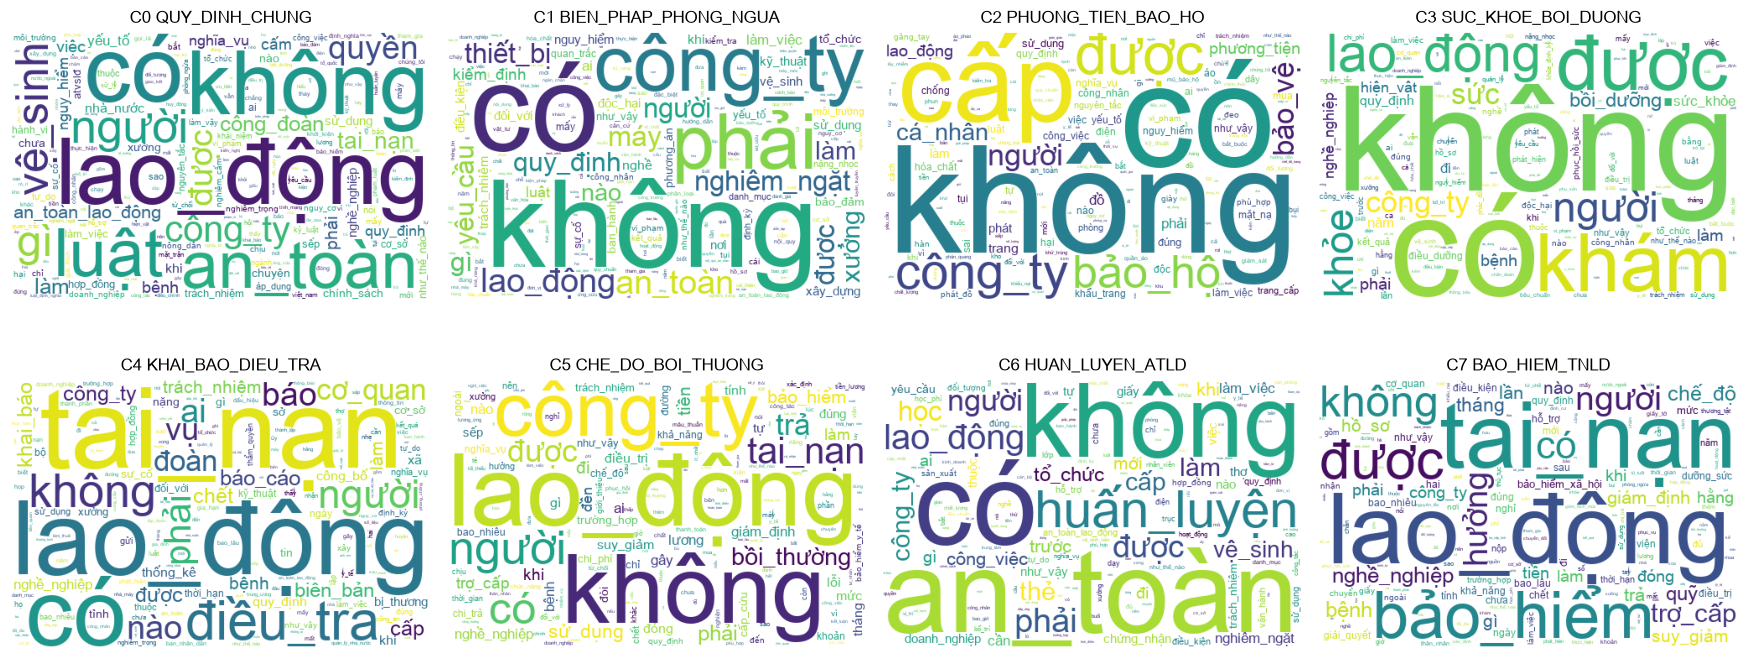

In [7]:
from wordcloud import WordCloud
FONT = "/System/Library/Fonts/Supplemental/Arial Unicode.ttf"
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (k, code_) in zip(axes.ravel(), sorted(LABEL_CODES.items())):
    text = " ".join(df.loc[df.label_id == k, "question_clean"])
    wc = WordCloud(width=500, height=320, background_color="white", font_path=FONT, collocations=False,
                   regexp=r"\S+").generate(text)
    ax.imshow(wc); ax.set_title(f"C{k} {code_}"); ax.axis("off")
savefig("eda_wordcloud")

In [8]:
# Top từ đặc trưng mỗi lớp (TF-IDF trung bình trên train)
tr = df[df.split == "train"]
v = tfidf(); X = v.fit_transform(tr.question_clean); vocab = np.array(v.get_feature_names_out())
top = {LABEL_CODES[k]: ", ".join(vocab[np.asarray(X[(tr.label_id == k).to_numpy()].mean(0)).ravel().argsort()[::-1][:8]])
       for k in sorted(LABEL_CODES)}
RESULTS["top_terms"] = top
pd.Series(top, name="top_terms").to_frame()

,top_terms
QUY_DINH_CHUNG,"lao_động, luật, vệ_sinh lao_động, có, vệ_sinh,..."
BIEN_PHAP_PHONG_NGUA,"không, có, yêu_cầu, thiết_bị, phải, an_toàn, m..."
PHUONG_TIEN_BAO_HO,"bảo_hộ, không, có, cấp, bảo_vệ, phương_tiện, c..."
SUC_KHOE_BOI_DUONG,"khám, bồi_dưỡng, khỏe, sức, sức khỏe, hiện_vật..."
KHAI_BAO_DIEU_TRA,"điều_tra, tai_nạn, đoàn, lao_động, tai_nạn lao..."
CHE_DO_BOI_THUONG,"công_ty, bồi_thường, tai_nạn, trả, lao_động, n..."
HUAN_LUYEN_ATLD,"huấn_luyện, an_toàn, huấn_luyện an_toàn, có, k..."
BAO_HIEM_TNLD,"bảo_hiểm, tai_nạn, tai_nạn lao_động, lao_động,..."


## 3. Tiền xử lý

1. Chuẩn hóa Unicode NFC, chữ thường, bỏ URL/email/HTML/ký tự đặc biệt.
2. Tách từ tiếng Việt bằng `underthesea.word_tokenize` (vd *bảo hộ lao động* -> `bảo_hộ_lao_động`).
3. Lọc stopwords (`data/stopwords_vi_legal.txt`), **giữ lại từ phủ định/điều kiện** (không, chưa, cấm, được, phải, nếu...).
4. Vector hóa TF-IDF (1,2)-gram, `sublinear_tf`, `min_df=2`, `max_features=5000`, **fit chỉ trên train** (nằm trong `Pipeline`).

In [9]:
ex = df.sample(4, random_state=RANDOM_STATE)[["question"]].copy()
ex["normalize"] = ex.question.map(normalize)
ex["full (tách từ + stopwords)"] = ex.question.map(preprocess)
ex["không tách từ"] = ex.question.map(lambda q: preprocess(q, segment_words=False, drop_stopwords=False))
RESULTS["preprocess_examples"] = ex.to_dict("records")
ex

,question,normalize,full (tách từ + stopwords),không tách từ
526,"Đồ bảo hộ toàn hàng chợ không có tem mác gì, c...",đồ bảo hộ toàn hàng chợ không có tem mác gì cô...,đồ bảo_hộ toàn hàng chợ không có tem_mác gì cô...,đồ bảo hộ toàn hàng chợ không có tem mác gì cô...
354,Phương án an toàn xây xưởng mới,phương án an toàn xây xưởng mới,phương_án an_toàn xây xưởng mới,phương án an toàn xây xưởng mới
168,Công ty ép tôi ký giấy nói tai nạn xảy ra ngoà...,công ty ép tôi ký giấy nói tai nạn xảy ra ngoà...,công_ty ép ký giấy nói tai_nạn xảy ngoài giờ l...,công ty ép tôi ký giấy nói tai nạn xảy ra ngoà...
135,Mặt trận Tổ quốc Việt Nam có trách nhiệm gì tr...,mặt trận tổ quốc việt nam có trách nhiệm gì tr...,mặt_trận tổ_quốc việt_nam có trách_nhiệm gì cô...,mặt trận tổ quốc việt nam có trách nhiệm gì tr...


## 4–5. Mô hình và tinh chỉnh siêu tham số

4 mô hình: **Multinomial Naive Bayes** (baseline), **Logistic Regression** (softmax, cross-entropy),
**LinearSVC** (hinge / squared hinge), **Random Forest** (bagging cây quyết định).
`GridSearchCV` với `StratifiedGroupKFold(5)` trên tập train (nhóm theo `seed_id`), tối ưu **Macro-F1**.
Chọn mô hình tốt nhất theo **Macro-F1 trên validation**. Test và test thật được báo cáo cho mọi mô hình để so sánh,
nhưng **không** dùng để chọn mô hình hay siêu tham số. Macro-F1 tính trên các lớp có mặt trong nhãn thật của từng tập
(test thật không có đủ 8 lớp).

In [10]:
tr, va, te = (df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"])
evals = {"val": va, "test": te}
if real is not None: evals["real"] = real
fitted, rows = {}, []
for name, (pipe, grid) in build_models().items():
    gs, row = fit_eval(name, pipe, grid, tr, evals)
    fitted[name] = gs.best_estimator_; rows.append(row)
    print(f"{name:20s} best={gs.best_params_}  cv={gs.best_score_:.4f}  val={row['val_macro_f1']:.4f}  ({row['fit_seconds']}s)")
res = pd.DataFrame(rows).set_index("model")
RESULTS["models"] = json.loads(res.to_json(orient="index"))

MultinomialNB        best={'clf__alpha': 0.5}  cv=0.7800  val=0.8121  (1.8s)


LogisticRegression   best={'clf__C': 1.0, 'clf__class_weight': 'balanced'}  cv=0.8358  val=0.8614  (0.5s)


LinearSVC            best={'clf__C': 1.0, 'clf__class_weight': 'balanced', 'clf__loss': 'hinge'}  cv=0.8282  val=0.8693  (0.4s)


RandomForest         best={'clf__max_depth': 50, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}  cv=0.8170  val=0.8025  (3.4s)


## 6. Đánh giá và so sánh mô hình

In [11]:
cols = ["cv_macro_f1", "train_macro_f1", "val_accuracy", "val_macro_precision", "val_macro_recall", "val_macro_f1",
        "test_accuracy", "test_macro_f1"] + (["real_accuracy", "real_macro_f1"] if real is not None else []) + ["fit_seconds"]
table = res[cols].round(4)
best = res.val_macro_f1.idxmax(); RESULTS["best_model"] = best  # chọn trên số chưa làm tròn
print("Mô hình tốt nhất theo val Macro-F1:", best)
table

Mô hình tốt nhất theo val Macro-F1: LinearSVC


,cv_macro_f1,train_macro_f1,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,test_accuracy,test_macro_f1,real_accuracy,real_macro_f1,fit_seconds
model,,,,,,,,,,,
MultinomialNB,0.7800,0.9833,0.8174,0.8240,0.8200,0.8121,0.8609,0.8595,0.7857,0.5481,1.8
LogisticRegression,0.8358,0.9903,0.8609,0.8652,0.8633,0.8614,0.9043,0.9033,0.7381,0.6030,0.5
LinearSVC,0.8282,0.9991,0.8696,0.8719,0.8717,0.8693,0.9087,0.9051,0.7857,0.6200,0.4
RandomForest,0.8170,1.0000,0.8043,0.8143,0.8050,0.8025,0.8609,0.8619,0.6667,0.5116,3.4


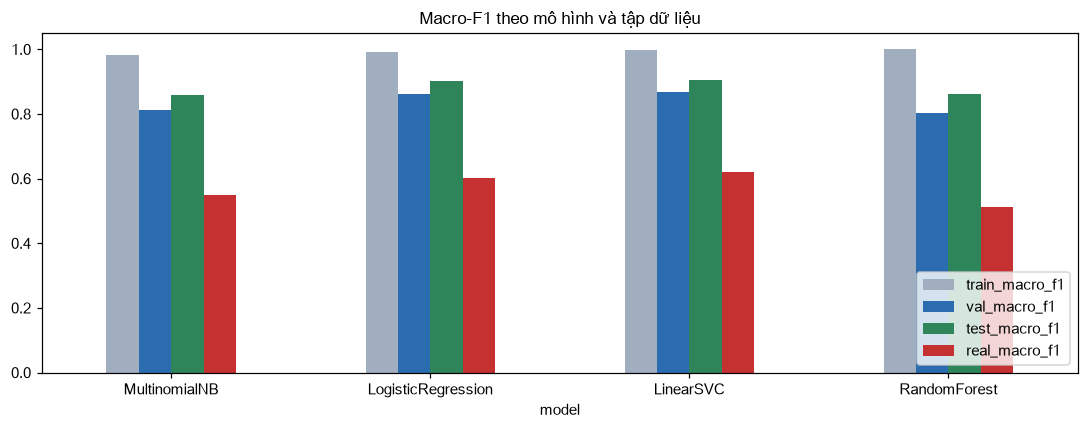

In [12]:
plot_cols = ["train_macro_f1", "val_macro_f1", "test_macro_f1"] + (["real_macro_f1"] if real is not None else [])
table[plot_cols].plot.bar(figsize=(10, 4), rot=0, color=["#a0aec0", "#2b6cb0", "#2f855a", "#c53030"][:len(plot_cols)])
plt.ylim(0, 1.05); plt.title("Macro-F1 theo mô hình và tập dữ liệu"); plt.legend(loc="lower right")
savefig("model_comparison")

In [13]:
# Overfitting / underfitting: chênh lệch train - val
gap = (table.train_macro_f1 - table.val_macro_f1).round(4).rename("train_minus_val")
RESULTS["train_val_gap"] = gap.to_dict()
gap.to_frame()

,train_minus_val
model,
MultinomialNB,0.1712
LogisticRegression,0.1289
LinearSVC,0.1298
RandomForest,0.1975


In [14]:
best_pipe = fitted[best]
y_pred_te = best_pipe.predict(te.question_clean)
rep = classification_report(te.label_id, y_pred_te, target_names=CODES, digits=4, output_dict=True, zero_division=0)
RESULTS["per_class_test"] = {c: {k: round(v, 4) for k, v in rep[c].items()} for c in CODES}
print(classification_report(te.label_id, y_pred_te, target_names=CODES, digits=4, zero_division=0))

                      precision    recall  f1-score   support

      QUY_DINH_CHUNG     0.6786    0.7600    0.7170        25
BIEN_PHAP_PHONG_NGUA     0.8148    0.7333    0.7719        30
  PHUONG_TIEN_BAO_HO     0.8846    0.9200    0.9020        25
  SUC_KHOE_BOI_DUONG     0.9667    0.9667    0.9667        30
   KHAI_BAO_DIEU_TRA     0.9355    0.9667    0.9508        30
   CHE_DO_BOI_THUONG     1.0000    0.9667    0.9831        30
     HUAN_LUYEN_ATLD     0.9677    1.0000    0.9836        30
       BAO_HIEM_TNLD     1.0000    0.9333    0.9655        30

            accuracy                         0.9087       230
           macro avg     0.9060    0.9058    0.9051       230
        weighted avg     0.9114    0.9087    0.9092       230



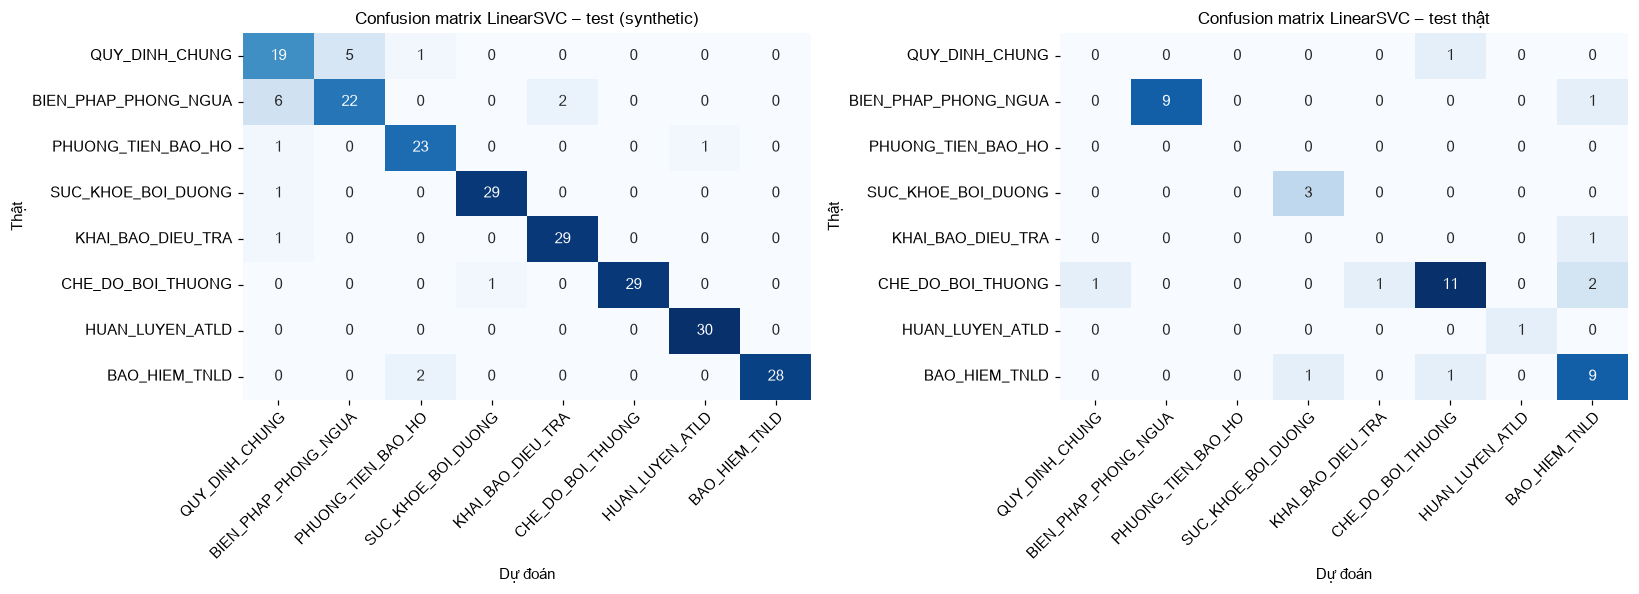

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (name, d) in zip(axes, [("test (synthetic)", te)] + ([("test thật", real)] if real is not None else [])):
    cm = confusion_matrix(d.label_id, best_pipe.predict(d.question_clean), labels=sorted(LABEL_CODES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CODES, yticklabels=CODES, ax=ax, cbar=False)
    ax.set_title(f"Confusion matrix {best} – {name}"); ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thật")
    # Căn phải + anchor để đầu chữ nhãn xoay nằm đúng dưới cột (mặc định căn giữa làm nhãn lệch trái)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    RESULTS[f"cm_{name}"] = cm.tolist()
if real is None: axes[1].axis("off")
savefig("confusion_matrix")

In [16]:
# Các cặp nhầm lẫn nhiều nhất (tổng trên 4 mô hình, test synthetic)
pairs = {}
for name, p in fitted.items():
    cm = confusion_matrix(te.label_id, p.predict(te.question_clean), labels=sorted(LABEL_CODES))
    for i in range(8):
        for j in range(8):
            if i != j and cm[i, j]: pairs[(CODES[i], CODES[j])] = pairs.get((CODES[i], CODES[j]), 0) + cm[i, j]
conf = pd.Series(pairs).sort_values(ascending=False).head(8)
RESULTS["top_confusions"] = {f"{a} -> {b}": int(v) for (a, b), v in conf.items()}
conf.to_frame("so_lan_nham_4_model")

so_lan_nham_4_model
BIEN_PHAP_PHONG_NGUA QUY_DINH_CHUNG                         30
QUY_DINH_CHUNG       BIEN_PHAP_PHONG_NGUA                   13
KHAI_BAO_DIEU_TRA    QUY_DINH_CHUNG                         11
BIEN_PHAP_PHONG_NGUA KHAI_BAO_DIEU_TRA                       6
CHE_DO_BOI_THUONG    SUC_KHOE_BOI_DUONG                      5
BAO_HIEM_TNLD        CHE_DO_BOI_THUONG                       4
                     PHUONG_TIEN_BAO_HO                      4
SUC_KHOE_BOI_DUONG   QUY_DINH_CHUNG                          4

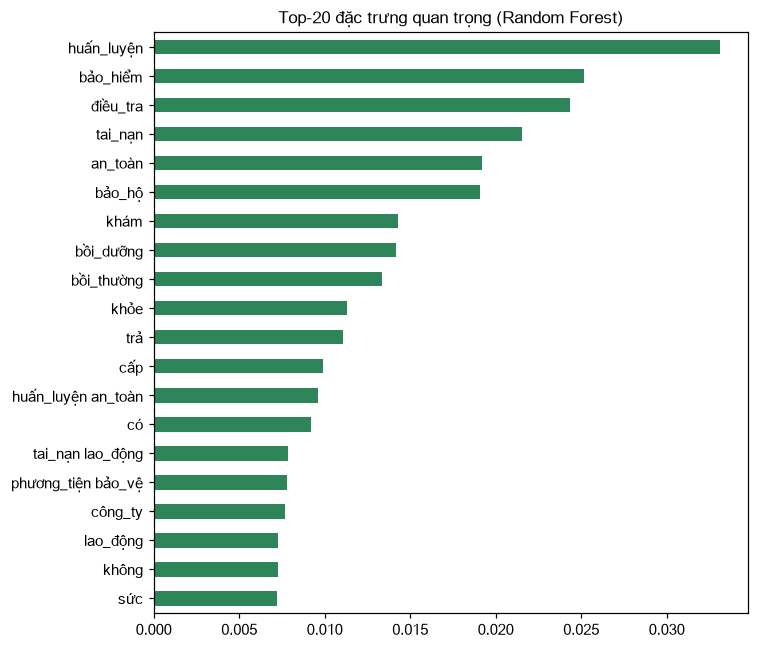

In [17]:
# Feature importance (Random Forest) và hệ số LinearSVC
rf = fitted["RandomForest"]; names = rf.named_steps["tfidf"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=names).sort_values(ascending=False).head(20)
imp[::-1].plot.barh(figsize=(7, 6), color="#2f855a"); plt.title("Top-20 đặc trưng quan trọng (Random Forest)")
savefig("rf_feature_importance")
RESULTS["rf_top_features"] = imp.round(5).to_dict()

## 7. Ablation study

Mỗi cặp so sánh chỉ khác **một** yếu tố (cùng mô hình tốt nhất, cùng siêu tham số, cùng split).
Cấu hình không tách từ không lọc stopwords (danh sách stopwords ở dạng đã tách từ), nên #2 so với #4.
Báo cáo Macro-F1 trên val, test và độ lệch chuẩn qua 5-fold CV nhóm trên train.

In [18]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
ABL = {
    "#1 Full (tách từ + stopwords + 1-2gram)": dict(seg=True,  sw=True,  ng=(1, 2)),
    "#2 Không tách từ (không stopwords, 1-2gram)": dict(seg=False, sw=False, ng=(1, 2)),
    "#3 Chỉ unigram (tách từ + stopwords)": dict(seg=True,  sw=True,  ng=(1, 1)),
    "#4 Không lọc stopwords (tách từ, 1-2gram)": dict(seg=True,  sw=False, ng=(1, 2)),
    "#5 Không tách từ + unigram": dict(seg=False, sw=False, ng=(1, 1)),
}
cache = {}
def texts(d, seg, sw):
    key = (id(d), seg, sw)
    if key not in cache: cache[key] = d.question.map(lambda q: preprocess(q, segment_words=seg, drop_stopwords=sw))
    return cache[key]
abl_rows = []
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, c in ABL.items():
    p = clone(best_pipe); p.set_params(tfidf__ngram_range=c["ng"])
    Xtr = texts(tr, c["seg"], c["sw"])
    cvs = cross_val_score(clone(p), Xtr, tr.label_id, groups=tr.seed_id, cv=cv, scoring="f1_macro")
    p.fit(Xtr, tr.label_id)
    row = {"config": name, "cv_f1_mean": cvs.mean(), "cv_f1_std": cvs.std(),
           "val_f1": scores(va.label_id, p.predict(texts(va, c["seg"], c["sw"])))["macro_f1"],
           "test_f1": scores(te.label_id, p.predict(texts(te, c["seg"], c["sw"])))["macro_f1"],
           "n_features": len(p.named_steps["tfidf"].vocabulary_)}
    if real is not None:
        row["real_f1"] = scores(real.label_id, p.predict(texts(real, c["seg"], c["sw"])))["macro_f1"]
    abl_rows.append(row)
abl = pd.DataFrame(abl_rows).set_index("config").round(4)
RESULTS["ablation"] = json.loads(abl.to_json(orient="index"))
abl

,cv_f1_mean,cv_f1_std,val_f1,test_f1,n_features,real_f1
config,,,,,,
#1 Full (tách từ + stopwords + 1-2gram),0.8282,0.0662,0.8693,0.9051,2524,0.6200
"#2 Không tách từ (không stopwords, 1-2gram)",0.8215,0.0597,0.8670,0.9293,3363,0.5859
#3 Chỉ unigram (tách từ + stopwords),0.8318,0.0530,0.8780,0.8806,819,0.6093
"#4 Không lọc stopwords (tách từ, 1-2gram)",0.8139,0.0699,0.8877,0.8923,2961,0.6204
#5 Không tách từ + unigram,0.8126,0.0577,0.8704,0.9139,804,0.5549


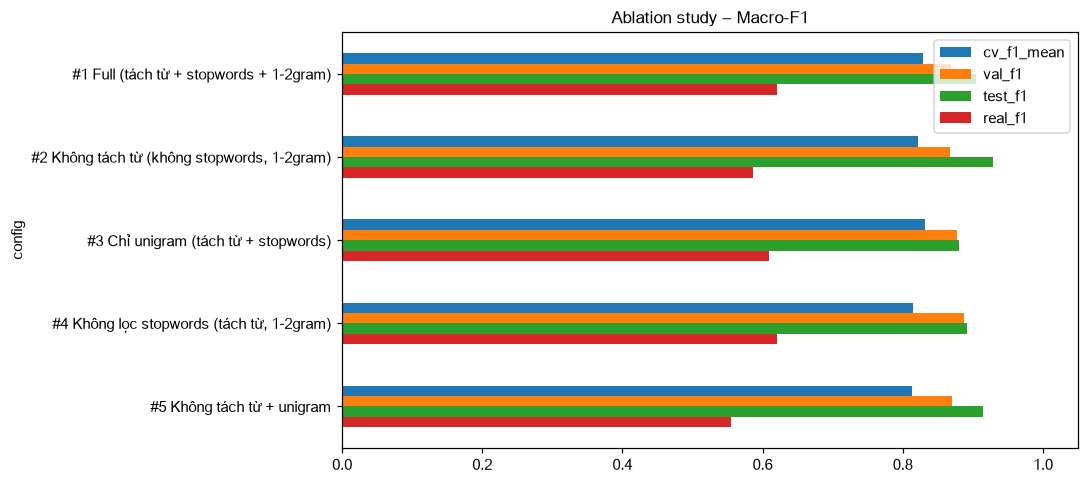

In [19]:
ax = abl[["cv_f1_mean", "val_f1", "test_f1"] + (["real_f1"] if real is not None else [])].plot.barh(
    figsize=(10, 4.5), xerr=None); ax.invert_yaxis(); ax.set_xlim(0, 1.05); ax.set_title("Ablation study – Macro-F1")
savefig("ablation")

## 8. Phân tích lỗi

In [20]:
err = te.assign(pred=y_pred_te)
err = err[err.label_id != err.pred]
err["true_code"] = err.label_id.map(LABEL_CODES); err["pred_code"] = err.pred.map(LABEL_CODES)
print("Số câu sai trên test synthetic:", len(err), "/", len(te))
print("Lỗi theo văn phong:"); print(err["style"].value_counts().to_string())
RESULTS["n_errors_test"] = int(len(err)); RESULTS["errors_by_style"] = err["style"].value_counts().to_dict()
RESULTS["error_examples"] = err[["question", "article_id", "true_code", "pred_code", "style"]].head(15).to_dict("records")
err[["question", "article_id", "true_code", "pred_code", "style"]].head(15)

Số câu sai trên test synthetic: 21 / 230
Lỗi theo văn phong:
style
complaint    6
worker       5
hr           4
short        4
neutral      2


,question,article_id,true_code,pred_code,style
10,Công ty có được kỷ luật người lao động vi phạm...,7,QUY_DINH_CHUNG,BIEN_PHAP_PHONG_NGUA,neutral
13,Tôi quên móc dây an toàn một lần mà bị kỷ luật...,7,QUY_DINH_CHUNG,PHUONG_TIEN_BAO_HO,complaint
15,Công ty có quyền huy động người lao động tham ...,7,QUY_DINH_CHUNG,BIEN_PHAP_PHONG_NGUA,neutral
17,Quyền huy động người lao động tham gia ứng cứu...,7,QUY_DINH_CHUNG,BIEN_PHAP_PHONG_NGUA,hr
18,Công ty bắt tôi đang nghỉ ca cũng phải vào khắ...,7,QUY_DINH_CHUNG,BIEN_PHAP_PHONG_NGUA,complaint
19,Công ty huy động người ứng cứu,7,QUY_DINH_CHUNG,BIEN_PHAP_PHONG_NGUA,short
31,"Công ty hay nói xây dựng văn hóa an toàn, vậy ...",20,BIEN_PHAP_PHONG_NGUA,QUY_DINH_CHUNG,worker
32,Trách nhiệm phối hợp giữa người sử dụng lao độ...,20,BIEN_PHAP_PHONG_NGUA,QUY_DINH_CHUNG,hr
33,Công ty chỉ treo khẩu hiệu mà không làm gì để ...,20,BIEN_PHAP_PHONG_NGUA,QUY_DINH_CHUNG,complaint
34,Xây dựng văn hóa an toàn lao động,20,BIEN_PHAP_PHONG_NGUA,QUY_DINH_CHUNG,short


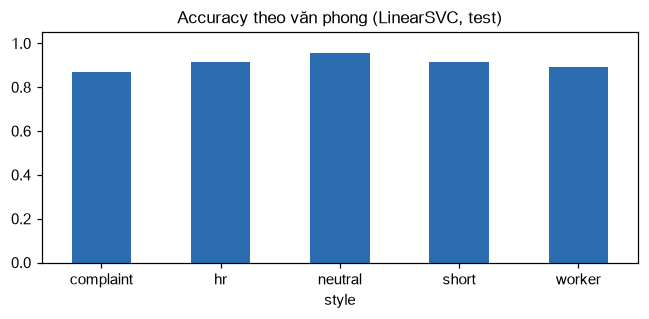

In [21]:
# Độ chính xác theo văn phong (câu ngắn có khó hơn không?)
acc_style = te.assign(ok=(y_pred_te == te.label_id)).groupby("style").ok.mean().round(4)
RESULTS["acc_by_style"] = acc_style.to_dict()
acc_style.plot.bar(rot=0, figsize=(6, 3), color="#2b6cb0"); plt.ylim(0, 1.05); plt.title(f"Accuracy theo văn phong ({best}, test)")
savefig("acc_by_style")

In [22]:
if real is not None:
    rp = best_pipe.predict(real.question_clean)
    real_err = real.assign(pred_code=pd.Series(rp).map(LABEL_CODES))[rp != real.label_id]
    RESULTS["real_error_examples"] = real_err[["question", "article_id", "label_code", "pred_code"]].head(15).to_dict("records")
    RESULTS["real_len_mean"] = float(real.question.str.split().str.len().mean())
    print("Độ dài TB câu thật:", round(RESULTS["real_len_mean"], 1), "âm tiết | synthetic:", round(df.n_words.mean(), 1))
    display(real_err[["question", "article_id", "label_code", "pred_code"]].head(15))

Độ dài TB câu thật: 106.2 âm tiết | synthetic: 20.5


,question,article_id,label_code,pred_code
6,Tôi là công nhân. Trên tuyến đường đi làm buổi...,39,CHE_DO_BOI_THUONG,BAO_HIEM_TNLD
9,"Tôi làm công việc khai thác mỏ hầm lò, bị tai ...",47,BAO_HIEM_TNLD,SUC_KHOE_BOI_DUONG
14,"Tôi bị tai nạn tại doanh nghiệp, mất khả năng ...",38,CHE_DO_BOI_THUONG,QUY_DINH_CHUNG
15,"Tôi sinh tháng 10/1963, làm công nhân đo đếm v...",22,BIEN_PHAP_PHONG_NGUA,BAO_HIEM_TNLD
21,Công ty tôi có một lao động đến giờ đi làm dắt...,35,KHAI_BAO_DIEU_TRA,BAO_HIEM_TNLD
22,Người lao động bị tai nạn do mình tự gây ra ho...,3,QUY_DINH_CHUNG,CHE_DO_BOI_THUONG
30,Tôi làm việc tại nhà máy sản xuất tinh bột mỳ ...,39,CHE_DO_BOI_THUONG,BAO_HIEM_TNLD
32,"Tôi xin hỏi, người lao động làm công việc cung...",40,CHE_DO_BOI_THUONG,KHAI_BAO_DIEU_TRA
34,"Công ty tôi có lao động đang hưởng lương hưu, ...",43,BAO_HIEM_TNLD,CHE_DO_BOI_THUONG


## 9. Tra cứu Điều luật (giai đoạn 2)

Trong lớp dự đoán, xếp hạng các Điều bằng cosine similarity giữa TF-IDF câu hỏi và TF-IDF văn bản Điều.
Đo Top-1/Top-3 accuracy theo `article_id` ở 3 chế độ: **oracle** (nhãn lớp thật, đo riêng retrieval),
**end-to-end** (nhãn dự đoán), **không phân loại** (tìm trên cả 62 Điều, baseline).

In [23]:
R = ArticleRetriever()
def eval_retrieval(d, name):
    pred = best_pipe.predict(d.question_clean)
    out = {}
    for k in (1, 3):
        out[f"oracle_top{k}"] = topk_accuracy(R, d.question_clean, d.article_id, d.label_id, k)
        out[f"e2e_top{k}"] = topk_accuracy(R, d.question_clean, d.article_id, pred, k)
        out[f"nofilter_top{k}"] = topk_accuracy(R, d.question_clean, d.article_id, [None] * len(d), k)
    multi = d.label_id.map(lambda l: len(LABELS[l][2]) > 1)
    out["oracle_top1_multi_article_classes"] = topk_accuracy(R, d.question_clean[multi], d.article_id[multi], d.label_id[multi], 1)
    return pd.Series(out, name=name)
ret = pd.concat([eval_retrieval(te, "test")] + ([eval_retrieval(real, "real")] if real is not None else []), axis=1).round(4)
RESULTS["retrieval"] = ret.to_dict()
ret

,test,real
oracle_top1,0.8217,0.5952
e2e_top1,0.7522,0.5000
nofilter_top1,0.6174,0.4286
oracle_top3,0.9913,0.9286
e2e_top3,0.9043,0.7143
nofilter_top3,0.8348,0.7381
oracle_top1_multi_article_classes,0.7657,0.5854


## 10. Phát hiện câu hỏi ngoài phạm vi (độ tin cậy)

Dùng Logistic Regression (có xác suất softmax) để lấy độ tin cậy lớp cao nhất. So sánh phân bố độ tin cậy giữa
câu trong phạm vi (test synthetic, test thật) và câu hỏi thật ngoài phạm vi (OOD). Ngưỡng chọn trên **val**, không trên OOD.

Ngưỡng (5% phân vị val) = 0.232
val              0.052
test             0.048
ood_real         0.165
real_in_scope    0.071


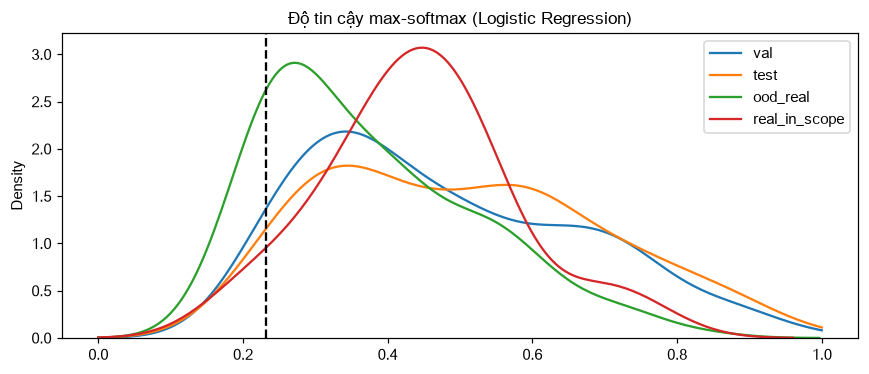

In [24]:
if ood is not None and len(ood):
    lr = fitted["LogisticRegression"]
    conf = {"val": lr.predict_proba(va.question_clean).max(1), "test": lr.predict_proba(te.question_clean).max(1),
            "ood_real": lr.predict_proba(ood.question_clean).max(1)}
    if real is not None: conf["real_in_scope"] = lr.predict_proba(real.question_clean).max(1)
    thr = float(np.quantile(conf["val"], 0.05))  # giữ 95% câu hợp lệ trên val
    rej = {k: float((v < thr).mean()) for k, v in conf.items()}
    RESULTS["ood"] = {"threshold": thr, "reject_rate": rej}
    print(f"Ngưỡng (5% phân vị val) = {thr:.3f}"); print(pd.Series(rej, name="tỷ lệ bị từ chối").round(3).to_string())
    plt.figure(figsize=(8, 3.5))
    for k, v in conf.items(): sns.kdeplot(v, label=k, clip=(0, 1))
    plt.axvline(thr, color="k", ls="--"); plt.legend(); plt.title("Độ tin cậy max-softmax (Logistic Regression)")
    savefig("ood_confidence")

In [25]:
import joblib
joblib.dump(best_pipe, MODELS_DIR / "best_classifier.joblib")
(ROOT / "reports").mkdir(exist_ok=True)
(ROOT / "reports" / "results.json").write_text(json.dumps(RESULTS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Đã lưu model và reports/results.json")

Đã lưu model và reports/results.json
